In [ ]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn shap

## Stage 1: Data Splits, Stratification, Cross-Validation, and Loss Functions (0:10 - 0:55)

## STEP 1: Generate the Synthetic Fraud Dataset

In [1]:
# STEP 1: Generate synthetic credit card fraud dataset
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

np.random.seed(42)

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    weights=[0.95, 0.05],   # 95% legitimate, 5% fraud
    flip_y=0.02,
    random_state=42
)

feature_names = [f"txn_feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["is_fraud"] = y

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['is_fraud'].value_counts(normalize=True)}")

Dataset shape: (10000, 21)
Class distribution:
is_fraud
0    0.9406
1    0.0594
Name: proportion, dtype: float64


## STEP 2: Train / Validation / Test Split (Naive vs. Stratified)

In [5]:
# STEP 2a: Naive random split -- observe class distribution drift
from sklearn.model_selection import train_test_split

X_all = df.drop("is_fraud", axis=1).values
y_all = df["is_fraud"].values

X_temp, X_test_naive, y_temp, y_test_naive = train_test_split(
    X_all, y_all, test_size=0.15, random_state=0   # no stratify
)
X_train_naive, X_val_naive, y_train_naive, y_val_naive = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=0  # ~15% of original
)

print("=== NAIVE SPLIT (no stratification) ===")
print(f"Train fraud rate:  {y_train_naive.mean():.4f}")
print(f"Val fraud rate:    {y_val_naive.mean():.4f}")
print(f"Test fraud rate:   {y_test_naive.mean():.4f}")

=== NAIVE SPLIT (no stratification) ===
Train fraud rate:  0.0594
Val fraud rate:    0.0588
Test fraud rate:   0.0600


In [3]:
# STEP 2b: Stratified split -- preserves class proportions
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

print("\n=== STRATIFIED SPLIT ===")
print(f"Train fraud rate:  {y_train.mean():.4f}")
print(f"Val fraud rate:    {y_val.mean():.4f}")
print(f"Test fraud rate:   {y_test.mean():.4f}")
print(f"\nSplit sizes -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


=== STRATIFIED SPLIT ===
Train fraud rate:  0.0594
Val fraud rate:    0.0595
Test fraud rate:   0.0593

Split sizes -> Train: 7004, Val: 1496, Test: 1500


## STEP 3: Stratified K-Fold Cross-Validation (Preferred)

In [ ]:
# STEP 3: Stratified K-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

cv_scores = cross_val_score(
    baseline_model, X_train, y_train,
    cv=skf,
    scoring="f1"
)

print("=== Stratified 5-Fold CV (F1 Score) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean:   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

## STEP 4: Loss Functions -- MSE vs. CrossEntropy

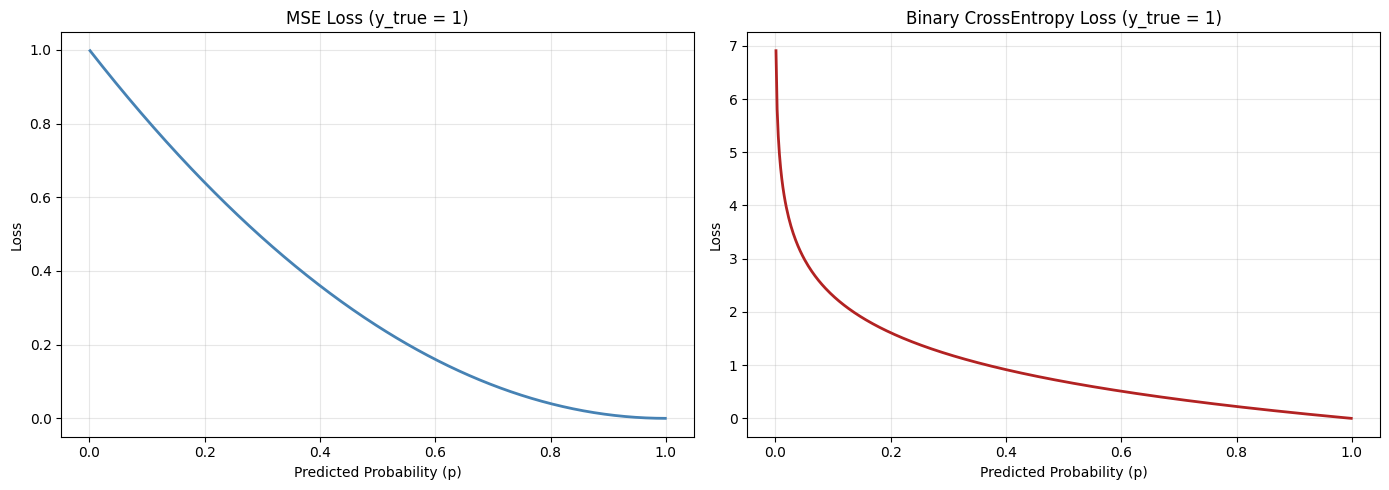

In [6]:
# STEP 4: MSE vs. CrossEntropy -- mathematical comparison
import matplotlib.pyplot as plt

y_true_example = 1.0  # true label: fraud

p = np.linspace(0.001, 0.999, 500)  # predicted probability

# MSE loss for a single sample: (y_true - p)^2
mse_loss = (y_true_example - p) ** 2

# Binary CrossEntropy for a single sample: -[y*log(p) + (1-y)*log(1-p)]
bce_loss = -(y_true_example * np.log(p) + (1 - y_true_example) * np.log(1 - p))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p, mse_loss, color="steelblue", linewidth=2)
axes[0].set_title("MSE Loss (y_true = 1)")
axes[0].set_xlabel("Predicted Probability (p)")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(p, bce_loss, color="firebrick", linewidth=2)
axes[1].set_title("Binary CrossEntropy Loss (y_true = 1)")
axes[1].set_xlabel("Predicted Probability (p)")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("step4_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Demonstrate the gradient difference at a specific wrong prediction
p_wrong = 0.05  # model predicts 5% fraud probability for an actual fraud case
print(f"At p = {p_wrong} (true label = 1):")
print(f"  MSE loss:          {(1 - p_wrong)**2:.4f}")
print(f"  CrossEntropy loss: {-np.log(p_wrong):.4f}")
print(f"  MSE gradient:      {2 * (p_wrong - 1):.4f}")
print(f"  CE gradient:       {-1/p_wrong:.4f}")
print("\nCrossEntropy gradient is ~10x stronger -- the model learns faster from mistakes.")

## Stage 2: Bias-Variance Diagnostics, Regularization, and Learning Curves (1:10 - 1:55)

## STEP 5: Learning Curves -- Diagnosing Bias vs. Variance

In [ ]:
# STEP 5: Learning curves for bias-variance diagnosis
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, scoring="f1"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="steelblue")
    plt.fill_between(train_sizes, val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color="firebrick")
    plt.plot(train_sizes, train_mean, "o-", color="steelblue",
             linewidth=2, label="Training score")
    plt.plot(train_sizes, val_mean, "o-", color="firebrick",
             linewidth=2, label="Validation score")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel(f"{scoring.upper()} Score")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(f"step5_{title.replace(' ', '_').lower()}.png", dpi=150,
                bbox_inches="tight")
    plt.show()

In [ ]:
# STEP 5a: High-bias model (underfitting example)
from sklearn.linear_model import LogisticRegression

simple_model = LogisticRegression(max_iter=1000, C=0.001, random_state=42)
plot_learning_curve(simple_model, "High Bias - Underfitting (C=0.001)",
                    X_train, y_train)

In [ ]:
# STEP 5b: High-variance model (overfitting example)
from sklearn.tree import DecisionTreeClassifier

complex_model = DecisionTreeClassifier(max_depth=None, random_state=42)
plot_learning_curve(complex_model, "High Variance - Overfitting (Unbounded Tree)",
                    X_train, y_train)

In [ ]:
# STEP 5c: Well-balanced model
balanced_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
plot_learning_curve(balanced_model, "Balanced - Good Fit (C=1.0)",
                    X_train, y_train)

## STEP 6: L1 (Lasso) and L2 (Ridge) Regularization

In [ ]:
# STEP 6: L1 (Lasso) and L2 (Ridge) Regularization
from sklearn.linear_model import LogisticRegression

# L2 Regularization (Ridge) -- penalty='l2' is the default
ridge_model = LogisticRegression(
    penalty="l2",
    C=1.0,         # C = 1/lambda; smaller C = stronger regularization
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)
ridge_model.fit(X_train, y_train)

# L1 Regularization (Lasso) -- requires solver that supports L1
lasso_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    max_iter=1000,
    solver="saga",  # saga supports L1
    random_state=42
)
lasso_model.fit(X_train, y_train)

print("=== Coefficient Comparison ===")
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Ridge (L2)": ridge_model.coef_[0],
    "Lasso (L1)": lasso_model.coef_[0]
})
coef_df["L1_is_zero"] = np.abs(coef_df["Lasso (L1)"]) < 1e-6
print(coef_df.to_string(index=False))
print(f"\nFeatures zeroed out by Lasso: {coef_df['L1_is_zero'].sum()} / {len(feature_names)}")

In [ ]:
# STEP 6b: Visualize coefficient magnitudes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names, ridge_model.coef_[0], color="steelblue")
axes[0].set_title("Ridge (L2) Coefficients")
axes[0].axvline(x=0, color="black", linewidth=0.5)

axes[1].barh(feature_names, lasso_model.coef_[0], color="firebrick")
axes[1].set_title("Lasso (L1) Coefficients")
axes[1].axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("step6_regularization_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## STEP 7: Dropout Regularization (Conceptual, Framework-Agnostic)

In [ ]:
# STEP 7: Illustrative plot of Dropout effect on training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = np.arange(1, 51)

# Simulated curves illustrating the expected behavior
dropout_train = 0.5 * np.exp(-0.04 * epochs) + 0.12 + np.random.normal(0, 0.005, 50)
dropout_val   = 0.5 * np.exp(-0.03 * epochs) + 0.15 + np.random.normal(0, 0.008, 50)

no_drop_train = 0.5 * np.exp(-0.06 * epochs) + 0.05 + np.random.normal(0, 0.005, 50)
no_drop_val   = 0.5 * np.exp(-0.03 * epochs) + 0.10 + 0.004 * epochs + np.random.normal(0, 0.008, 50)

axes[0].plot(epochs, dropout_train, label="Train", color="steelblue")
axes[0].plot(epochs, dropout_val, label="Validation", color="firebrick")
axes[0].set_title("WITH Dropout (p=0.3)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, no_drop_train, label="Train", color="steelblue")
axes[1].plot(epochs, no_drop_val, label="Validation", color="firebrick")
axes[1].set_title("WITHOUT Dropout")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("step7_dropout_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 3: Full Evaluation Suite, SHAP Values, and Early Stopping (2:10 - 2:55)

## STEP 8: Train the Final Evaluation Model

In [8]:
# STEP 8: Train the final model for evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

eval_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        class_weight="balanced",  # upweight minority class
        random_state=42
    ))
])

eval_pipeline.fit(X_train, y_train)

y_val_pred = eval_pipeline.predict(X_val)
y_val_proba = eval_pipeline.predict_proba(X_val)[:, 1]

y_test_pred = eval_pipeline.predict(X_test)
y_test_proba = eval_pipeline.predict_proba(X_test)[:, 1]

print("Model trained. Predictions generated on validation and test sets.")

Model trained. Predictions generated on validation and test sets.


## STEP 9: Precision, Recall, and F1 for Imbalanced Classification

In [9]:
# STEP 9: Precision, Recall, F1
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("=== Test Set Metrics (Fraud = Positive Class) ===")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print()
print("Full Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Legitimate", "Fraud"]))

=== Test Set Metrics (Fraud = Positive Class) ===
  Precision: 0.1927
  Recall:    0.7079
  F1 Score:  0.3029

Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.81      0.89      1411
       Fraud       0.19      0.71      0.30        89

    accuracy                           0.81      1500
   macro avg       0.59      0.76      0.60      1500
weighted avg       0.93      0.81      0.85      1500



In [10]:
# STEP 9b: Manual calculation to build intuition
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

print("=== Manual Calculation ===")
print(f"  True Positives  (caught fraud):         {tp}")
print(f"  False Positives (false alarms):          {fp}")
print(f"  True Negatives  (correct legitimate):    {tn}")
print(f"  False Negatives (missed fraud):           {fn}")
print()
manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
manual_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
manual_f1 = 2 * manual_precision * manual_recall / (manual_precision + manual_recall) if (manual_precision + manual_recall) > 0 else 0
print(f"  Manual Precision: {manual_precision:.4f}")
print(f"  Manual Recall:    {manual_recall:.4f}")
print(f"  Manual F1:        {manual_f1:.4f}")

=== Manual Calculation ===
  True Positives  (caught fraud):         63
  False Positives (false alarms):          264
  True Negatives  (correct legitimate):    1147
  False Negatives (missed fraud):           26

  Manual Precision: 0.1927
  Manual Recall:    0.7079
  Manual F1:        0.3029


## STEP 10: Confusion Matrix Visualization

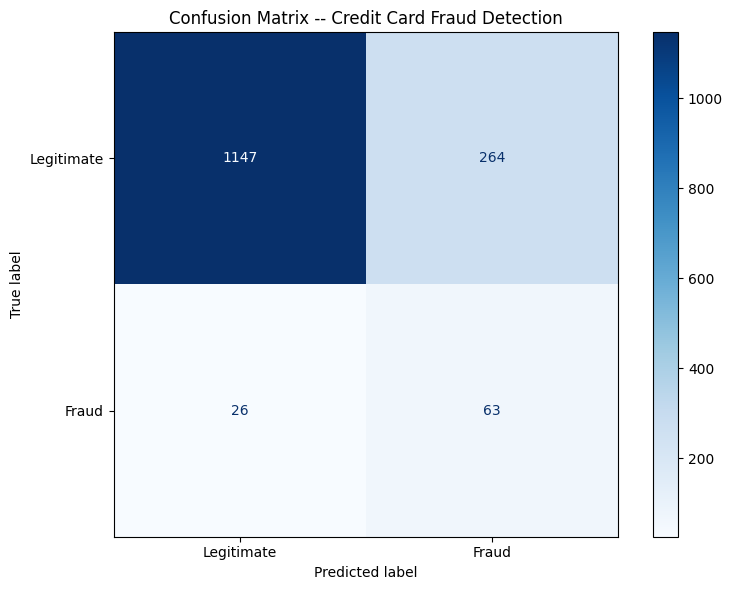

In [11]:
# STEP 10: Confusion Matrix heatmap
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["Legitimate", "Fraud"],
    cmap="Blues",
    ax=ax,
    values_format="d"
)
ax.set_title("Confusion Matrix -- Credit Card Fraud Detection")
plt.tight_layout()
plt.savefig("step10_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## STEP 11: AUC-ROC Curve

In [ ]:
# STEP 11: AUC-ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

auc_score = roc_auc_score(y_test, y_test_proba)
print(f"AUC-ROC Score: {auc_score:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_test_proba,
    name="Logistic Regression",
    ax=ax,
    color="steelblue",
    linewidth=2
)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC=0.5)")
ax.set_title(f"ROC Curve -- AUC = {auc_score:.4f}")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("step11_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# STEP 11b: Precision-Recall Curve (better for imbalanced data)
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

ap_score = average_precision_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba,
    name="Logistic Regression",
    ax=ax,
    color="firebrick",
    linewidth=2
)
ax.set_title(f"Precision-Recall Curve -- AP = {ap_score:.4f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("step11b_precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

## STEP 12: SHAP Values for Model Explainability (Preferred)

In [7]:
# STEP 12: SHAP Values for Explainability
import shap

explainer = shap.LinearExplainer(
    eval_pipeline.named_steps["classifier"],
    eval_pipeline.named_steps["scaler"].transform(X_train),
    feature_names=feature_names
)

X_test_scaled = eval_pipeline.named_steps["scaler"].transform(X_test)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print("(Each test sample has one SHAP value per feature)")

C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'eval_pipeline' is not defined

In [ ]:
# STEP 12a: Summary plot -- global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot -- Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.savefig("step12_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# STEP 12b: Force plot for a single prediction (first fraud case in test set)
fraud_indices = np.where(y_test == 1)[0]
if len(fraud_indices) > 0:
    sample_idx = fraud_indices[0]
    print(f"Explaining prediction for test sample {sample_idx}")
    print(f"  True label: {'Fraud' if y_test[sample_idx] == 1 else 'Legitimate'}")
    print(f"  Predicted probability: {y_test_proba[sample_idx]:.4f}")

    shap.initjs()
    force_plot = shap.force_plot(
        explainer.expected_value,
        shap_values[sample_idx],
        X_test_scaled[sample_idx],
        feature_names=feature_names
    )
    shap.save_html("step12_shap_force_plot.html", force_plot)
    print("Force plot saved to step12_shap_force_plot.html")

In [ ]:
# STEP 12c: Bar plot -- mean absolute SHAP values (feature importance ranking)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Mean |SHAP Value| -- Feature Importance Ranking")
plt.tight_layout()
plt.savefig("step12_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## STEP 13: Early Stopping (Conceptual, Framework-Agnostic) (Preferred)

In [ ]:
# STEP 13: Illustrative plot of Early Stopping behavior
np.random.seed(42)

n_epochs = 80
stopped_epoch = 55
best_epoch = 40

epochs = np.arange(1, n_epochs + 1)
train_loss = 0.6 * np.exp(-0.05 * epochs) + 0.04 + np.random.normal(0, 0.005, n_epochs)
val_loss = 0.6 * np.exp(-0.04 * epochs) + 0.08 + 0.002 * np.maximum(epochs - best_epoch, 0) + np.random.normal(0, 0.008, n_epochs)

# Only show up to the stopped epoch
train_loss_shown = train_loss[:stopped_epoch]
val_loss_shown = val_loss[:stopped_epoch]
epochs_shown = epochs[:stopped_epoch]

plt.figure(figsize=(10, 6))
plt.plot(epochs_shown, train_loss_shown, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(epochs_shown, val_loss_shown, label="Val Loss", color="firebrick", linewidth=2)

plt.axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.5,
            label=f"Best epoch ({best_epoch})")
plt.axvline(x=stopped_epoch, color="red", linestyle="--",
            linewidth=1.5, label=f"Stopped epoch ({stopped_epoch})")

plt.title("Training with Early Stopping (Illustrative)")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("step13_early_stopping.png", dpi=150, bbox_inches="tight")
plt.show()

## Closing Git Branch Activity (Final 5 min)

**Terminal command:**
```bash
# Navigate to the project directory
cd fraud-detection-evaluation

# Initialize a Git repo if not already done
git init

# Create and switch to a feature branch
git checkout -b feature/applied-ml-evaluation

# Stage all files
git add .

# Commit with a descriptive message
git commit -m "Add complete model evaluation pipeline for fraud detection

- Stratified train/val/test splits and 5-fold cross-validation
- MSE vs CrossEntropy loss comparison
- Learning curves for bias-variance diagnosis
- L1/L2 regularization with coefficient analysis
- Dropout regularization concepts
- Full metrics suite: precision, recall, F1, AUC-ROC, confusion matrix
- SHAP explainability plots
- Early stopping callback pattern"

# Verify the commit
git log --oneline -1
```